In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st

In [2]:
data_50 = pd.read_csv('data_50.csv')

In [3]:
data_50.head()

,normal,exponential,lognormal,cauchy
0,2.655327,4.133133,0.626336,-1.062030
1,5.262228,1.062530,0.349705,3.124187
2,4.110757,1.079954,1.947488,-1.671653
3,-3.055970,10.959957,0.131832,1.510911
4,3.035456,0.201304,5.693308,3.032844


## Примените на этой выборке бутстрап среднего. 
Посмотрите на получившееся бут-распределение: выглядит ли нормальной гистограмма? Какие результаты дают тесты нормальности и QQ-графики?

В ответе укажите p-value теста Д'Агостино-Пирсона, округлённое до 4 знака.



In [4]:
def boot_func(series, stat, reps=5000, seed=2112):

    boot_data = [] #складываем сюда результаты вычислений
    np.random.seed(seed=seed) #фиксируем "зерно" 
    
    #повторяем процедуру n раз
    for _ in range(reps):

        sample_data = series.sample(frac=1, replace=True) #генерируем бут-выборку
        sample_stat = stat(sample_data) #считаем статистику
        boot_data.append(sample_stat) #добавляем её в список

    return(np.array(boot_data))

In [15]:
means = boot_func(data_50.normal, np.mean)

In [16]:
import seaborn as sns

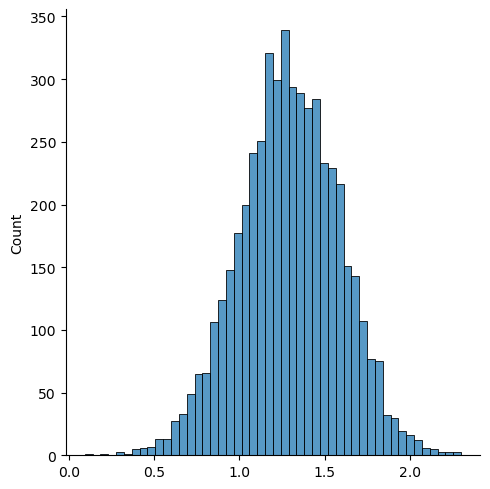

In [17]:
sns.displot(x = means)

In [18]:
import pingouin as pg

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

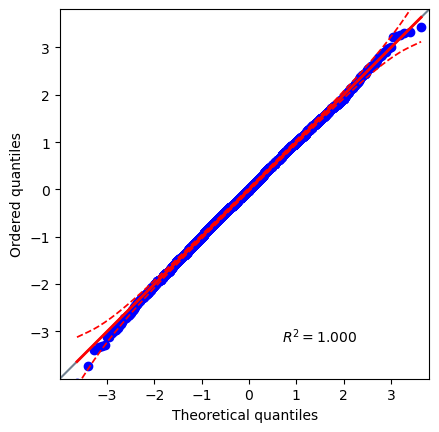

In [19]:
pg.qqplot(means)

In [20]:
st.normaltest(means)

NormaltestResult(statistic=np.float64(4.612256291323637), pvalue=np.float64(0.0996463216537104))

In [37]:
names = ['exponential','lognormal','cauchy']
means_exponential = boot_func(data_50.exponential, np.mean)
means_lognormal = boot_func(data_50.lognormal, np.mean)
means_cauchy = boot_func(data_50.cauchy, np.mean)
all_means_50 = [means_exponential,means_lognormal,means_cauchy]
for i in range(3):
    print( 'for ' , names[i] , st.normaltest(all_means_50[i]).pvalue )

for  exponential 7.738755865054332e-15
for  lognormal 5.628191389865519e-09
for  cauchy 2.63036685553864e-47


Однако не стоит забывать: ЦПТ — вещь асимптотическая. Она работает при условии, что размер выборки стремится к бесконечности; а значит, выборка большего размера вполне может дать нам нормальное бут-распределение.



In [32]:
data_1000 = pd.read_csv('data_1000.csv')

In [33]:
data_1000.head()

,normal,exponential,lognormal,cauchy
0,2.490185,1.170389,5.490941,-1.095701
1,1.172446,1.093998,1.911315,2.042327
2,0.440150,10.413298,1.258924,-2.359540
3,5.362370,2.573429,1.348536,6.835326
4,2.837313,2.703204,0.223479,-0.031521


In [38]:
names = ['exponential','lognormal','cauchy']
means_exponential = boot_func(data_1000.exponential, np.mean)
means_lognormal = boot_func(data_1000.lognormal, np.mean)
means_cauchy = boot_func(data_1000.cauchy, np.mean)
all_means_1000 = [means_exponential,means_lognormal,means_cauchy]
for i in range(3):
    print( 'for ' , names[i] , st.normaltest(all_means_1000[i]).pvalue )

for  exponential 0.4081366786722621
for  lognormal 0.02140854080050004
for  cauchy 2.7890608364042234e-132


Как вы помните, стандартное отклонение выборочных средних имеет своё название — стандартная ошибка среднего. Она отражает степень нашей неточности: чем больше стандартная ошибка, тем меньше мы уверены в том, насколько близко наше среднее находится к истинному. Стандартные ошибки лежат в основе статистического вывода, и от них зависит наше заключение о статистической значимости полученных закономерностей.

Стандартную ошибку можно оценить и с помощью бутстрапа: нужно просто посчитать стандартное отклонение бут-выборки. Давайте это и попробуем сделать!

Возьмите первый набор данных (где выборки по 50), сделайте бутстрап средних и посчитайте стандартные отклонения получившихся бут-выборок (ddof=1). Сопоставьте выборки и значения стандартных ошибок.

In [41]:
all_names = ['normal', 'exponential','lognormal','cauchy']
means_normal = boot_func(data_50.normal, np.mean)
means_exponential = boot_func(data_50.exponential, np.mean)
means_lognormal = boot_func(data_50.lognormal, np.mean)
means_cauchy = boot_func(data_50.cauchy, np.mean)
allest_means_50 = [means_normal,means_exponential,means_lognormal,means_cauchy]

In [42]:
for i in range(4):
    print( 'for ' , all_names[i] , np.std(allest_means_50[i]) )

for  normal 0.2933179742326255
for  exponential 0.36220362402700257
for  lognormal 0.22288860209522773
for  cauchy 2.9453046696135883


Бутстрап средних — это, конечно, хорошо. Но это лишь начало: бутстрап создавался для работы с гораздо менее "удобными" статистиками, для которых красивой формулы стандартной ошибки может и не быть. Например, с медианами.

Посчитайте стандартные ошибки для медиан (np.median()) и также сопоставьте их значения с выборками.



In [44]:
all_names = ['normal', 'exponential','lognormal','cauchy']
median_normal = boot_func(data_50.normal, np.median)
median_exponential = boot_func(data_50.exponential, np.median)
median_lognormal = boot_func(data_50.lognormal, np.median)
median_cauchy = boot_func(data_50.cauchy, np.median)
allest_medians_50 = [median_normal,median_exponential,median_lognormal,median_cauchy]
for i in range(4):
    print( 'for ' , all_names[i] , np.std(allest_medians_50[i]) )

for  normal 0.3979073323733277
for  exponential 0.24139758156650296
for  lognormal 0.19607586804963634
for  cauchy 0.5210688194229808


In [45]:
se_df = pd.DataFrame({
    'dist': all_names * 2,
    'stat': ['mean'] * 4 + ['median'] * 4,
    'se': [
        np.std(means_normal, ddof=1),
        np.std(means_exponential, ddof=1),
        np.std(means_lognormal, ddof=1),
        np.std(means_cauchy, ddof=1),

        np.std(median_normal, ddof=1),
        np.std(median_exponential, ddof=1),
        np.std(median_lognormal, ddof=1),
        np.std(median_cauchy, ddof=1)
    ]
})

In [46]:
se_df

,dist,stat,se
0,normal,mean,0.293347
1,exponential,mean,0.362240
2,lognormal,mean,0.222911
3,cauchy,mean,2.945599
4,normal,median,0.397947
5,exponential,median,0.241422
6,lognormal,median,0.196095
7,cauchy,median,0.521121


<Axes: xlabel='dist', ylabel='se'>

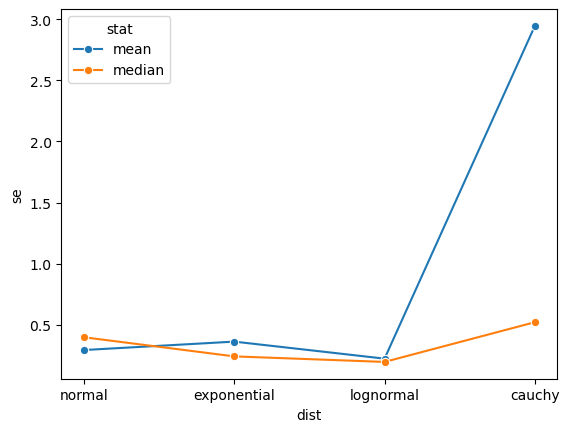

In [47]:
sns.lineplot(
    data=se_df,
    x='dist',
    y='se',
    hue='stat',
    marker='o'
)

Что можно видеть по графику:

- В случае нормального распределения стандартная ошибка среднего ниже, чем стандартная ошибка медианы. Иными словами, мы более уверены в точности нашей оценки среднего, чем нашей оценки медианы.
- В случае двух асимметричных распределений ситуация переворачивается: теперь мы больше уверены в точности нашей медианы. С ростом размера выборки эта закономерность, впрочем, может опять перевернуться в сторону среднего.
- Наиболее явный выигрыш для медианы наблюдается в случае распределения Коши. Это неудивительно: так как медиана менее чувствительна к экстремальным значениям, гигантские выбросы Коши не оказывают на неё такой разрушительный эффект. Поэтому, в отличие от среднего и дисперсии, медиана ГС в случае Коши вполне себе существует.

# Бутстрап-оценка смещения

Помимо стандартного отклонения, мы также можем посчитать среднее значение бут-распределения.

Это даст нам **бут-оценку значения статистики**.

Таким образом, у нас есть три величины:

| Обозначение | Значение |
|---|---|
| `θ` | истинное значение статистики, например среднее генеральной совокупности |
| `θ̂` | выборочное значение статистики, например выборочное среднее |
| `θ̃` | бут-оценка выборочного значения, например бут-оценка среднего |

---

## Смещение

`θ` и `θ̂` редко совпадают в реальности, но в среднем наша оценка должна попадать в точку.

Однако это справедливо не всегда: интересующая нас выборочная статистика может систематически оказываться ниже или выше `θ`.

Такое систематическое различие между `θ` и `θ̂` называют **смещением** (*bias*).

---

## Бутстрап-оценка смещения

На практике мы почти никогда не знаем истинное значение `θ`, а `θ̂` обычно есть только одно.

Поэтому истинное значение смещения узнать нельзя.

Однако с помощью бутстрапа можно посчитать `θ̃` и сравнить его с `θ̂`.

Формула бутстрап-оценки смещения:

$$
\widetilde{bias} = \hat{\theta} - \widetilde{\theta}
$$

---

## Задание

Возьмите данные с `50` наблюдениями и посчитайте смещение:

- для среднего;
- для медианы;

в каждой из выборок.

## Ответ

В ответе укажите самое маленькое по модулю значение смещения:

- для среднего;
- для медианы.

Значения необходимо округлить до `4` знаков после запятой.

Знак смещения указывать не нужно.

In [51]:
def boot_bias(series, stat, reps=5000, seed=2112):
    boot_data = []
    np.random.seed(seed)

    for _ in range(reps):
        sample_data = series.sample(frac=1, replace=True)
        sample_stat = stat(sample_data)
        boot_data.append(sample_stat)

    boot_data = np.array(boot_data)

    theta_hat = stat(series)          # статистика на исходной выборке
    theta_tilde = boot_data.mean()    # среднее bootstrap-распределения

    bias = theta_hat - theta_tilde

    return abs(bias)

In [52]:
samples = ['normal', 'exponential', 'lognormal', 'cauchy']

mean_biases = []
median_biases = []

for name in samples:
    series = data_50[name]

    mean_bias = boot_bias(series, np.mean)
    median_bias = boot_bias(series, np.median)

    mean_biases.append(mean_bias)
    median_biases.append(median_bias)

    print(name, 'mean bias:', mean_bias, 'median bias:', median_bias)

normal mean bias: 0.00044795191880853125 median bias: 0.06762045766139302
exponential mean bias: 0.003496155404943302 median bias: 0.04731081321451969
lognormal mean bias: 0.0035899195346853485 median bias: 0.009835381962708611
cauchy mean bias: 0.024632854311600116 median bias: 0.015292440607474145


In [53]:
round(min(mean_biases), 4)

np.float64(0.0004)

In [54]:
round(min(median_biases), 4)

np.float64(0.0098)

Вы могли заметить, что степень смещения у среднего систематически ниже, чем у медианы (за исключением, конечно же, Коши). Это следствие приятного теоретического свойства выборочного среднего: оно является несмещённой (unbiased) оценкой истинного среднего.

Медиана по сравнению со средним имеет более выраженные тенденции к смещению. Впрочем, оно не очень большое относительно стандартной ошибки, и поэтому сильно волноваться не стоит (но стоит запомнить это на будущее). В целом считается, что в симметричных распределениях медиана является несмещённой, но в асимметричных смещение может быть более выраженным.

Оценку смещения часто используют для того, чтобы подкорректировать границы доверительных интервалов, посчитанных с помощью бутстрапа. Их построением мы займёмся во второй части заданий урока.

## Часть 2: бутстрап и статистический вывод
Самая главная задача, для которой аналитик использует бутстрап — это задача статистического сравнения некоторой статистики между двумя выборками. Вы уже сравнивали средние с помощью t-теста и ANOVA; настало время перейти к другим статистикам.

Для этого мы слегка видоизменим нашу функцию для бутстрапа:

In [55]:
def two_sample_boot(x, y, stat, reps=5000, seed=2112):

    boot_data = []
    np.random.seed(seed=seed)

    for _ in range(reps):

        sample_x = x.sample(frac=1, replace=True)
        sample_y = y.sample(frac=1, replace=True)
        sample_stat_diff = stat(sample_x) - stat(sample_y)
        boot_data.append(sample_stat_diff)

    return(np.array(boot_data))

Теперь она принимает на вход две выборки, а внутри неё считается разница между двумя статистиками.

Также в этой части мы будем использовать другой набор данных. 

In [58]:
data_two_sample = pd.read_csv('data_two_sample.csv')

In [59]:
data_two_sample.head()

,control,test_1,test_2,test_3
0,1.309448,1.517011,34.004612,3.081587
1,0.401232,4.384583,-4.235684,0.713261
2,0.324160,-0.551325,2.902821,1.932041
3,-4.537220,2.774734,24.228366,4.407164
4,5.112698,1.546994,27.855371,1.132654


In [60]:
data_two_sample.shape

(1000, 4)

In [61]:
def std_ddof0(x):
    return np.std(x, ddof=0)

In [62]:
control = data_two_sample['control']

tests = {
    'test_1': data_two_sample['test_1'],
    'test_2': data_two_sample['test_2'],
    'test_3': data_two_sample['test_3']
}

stats = {
    'mean': np.mean,
    'median': np.median,
    'std': std_ddof0
}

results = []

for test_name, test_data in tests.items():
    for stat_name, stat_func in stats.items():
        
        boot_diff = two_sample_boot(
            x=control,
            y=test_data,
            stat=stat_func
        )
        
        theta_hat = stat_func(control) - stat_func(test_data)
        se = np.std(boot_diff, ddof=1)
        
        lower = theta_hat - 1.96 * se
        upper = theta_hat + 1.96 * se
        
        significant = (lower > 0) or (upper < 0)
        
        results.append({
            'comparison': f'control - {test_name}',
            'stat': stat_name,
            'theta_hat': theta_hat,
            'se': se,
            'lower': lower,
            'upper': upper,
            'significant': significant
        })

results_df = pd.DataFrame(results)
results_df.round(4)

,comparison,stat,theta_hat,se,lower,upper,significant
0,control - test_1,mean,-0.1671,0.0935,-0.3502,0.0161,False
1,control - test_1,median,-0.1842,0.1313,-0.4416,0.0733,False
2,control - test_1,std,0.0646,0.0662,-0.0651,0.1943,False
3,control - test_2,mean,0.8365,0.6923,-0.5203,2.1934,False
4,control - test_2,median,0.1538,0.8681,-1.5478,1.8554,False
5,control - test_2,std,-19.7440,0.5261,-20.7751,-18.7129,True
6,control - test_3,mean,-0.2407,0.1035,-0.4436,-0.0379,True
7,control - test_3,median,0.5910,0.1019,0.3913,0.7907,True
8,control - test_3,std,-0.3384,0.2254,-0.7802,0.1034,False


Итого что мы имеем:

- control и test_2 статистически значимо различаются по стандартному отклонению. Это можно было увидеть невооружённым глазом: в ГС стандартное отклонение test_2 в 10 раз превышает стандартное отклонение контроля.
 - control и test_3 статистически значимо различаются по медианам. Можно увидеть, что распределение в группе test_3 радикально отличается от контроля, являясь ярко асимметричным (если точнее, то оно логнормальное) .
- Также control и test_3 статистически значимо различаются по средним. Однако на самом деле это ошибка I рода: в ГС, откуда были сгенерированы эти данные, средние на самом деле одинаковые. В этом нет ничего удивительного: статистический вывод позволяет нам контролировать вероятность ошибки I рода, но никогда не избавляет нас от этих ошибок.

Нормальный интервал — это, конечно, просто и понятно (особенно если вы уже привыкли к классической формуле). Однако у него есть очевидный недостаток: он требует нормальности бут-распределения. Чем меньше оно похоже на нормальное, тем менее точным будет результирующий интервал.

Поэтому обычно на практике интервал считают совсем иначе: путём расчёта соответствующих квантилей (процентилей) бут-распределения! Этот подход демонстрирует Анатолий в лекции.

Пересчитайте 95%-ые доверительные интервалы из прошлого задания, используя процентильный метод (нам нужны процентили 2.5% и 97.5%). В ответе укажите нижнюю и верхнюю границы доверительного интервала для разницы в стандартных отклонениях между группами control и test_3.

Значения округлите до 4 знака.

In [63]:
boot_std_diff = two_sample_boot(
    x=data_two_sample['control'],
    y=data_two_sample['test_3'],
    stat=std_ddof0
)

In [64]:
lower = np.percentile(boot_std_diff, 2.5)
upper = np.percentile(boot_std_diff, 97.5)

round(lower, 4), round(upper, 4)

(np.float64(-0.7873), np.float64(0.0899))

# BCa-доверительные интервалы

Классический процентильный интервал крайне прост в реализации и в целом неплох, но всё ещё не идеален.

Более продвинутый подход к его построению делает коррекцию на смещение, учитывая возможную асимметрию бут-распределения.

Такие интервалы называются **bias-corrected and accelerated**, или **BCa**.

---

## Дополнительные величины

При расчёте BCa-интервала дополнительно высчитываются следующие величины:

| Обозначение | Описание |
|---|---|
| `z₀` | значение смещения в z-единицах |
| `acc` | константа ускорения |

---

## `z₀`

`z₀` — это значение смещения в z-единицах.

Оно считается несколько иначе по сравнению с формулой из прошлой части заданий.

---

## `acc`

`acc` — константа ускорения, дополнительно корректирующая значения границ.

При симметричном распределении она равна `0`.

В таком случае мы получаем просто скорректированный на смещение интервал.

---

## Примечание

Алгоритм расчёта такого интервала довольно сложный, поэтому код уже написан за вас на основе модифицированной функции из первого шага.

In [65]:
def boot_bca(x, y, stat, conf_level=0.95, reps=5000, seed=2112):

    boot_data = []
    np.random.seed(seed=seed)
    sample_stat = stat(x) - stat(y) #выборочное различие

    for _ in range(reps):

        sample_x = x.sample(frac=1, replace=True)
        sample_y = y.sample(frac=1, replace=True)
        sample_stat_diff = stat(sample_x) - stat(sample_y)
        boot_data.append(sample_stat_diff)

    boot_data = np.array(boot_data)
    
    #оцениваем смещение с помощью функции нормального распределения
    #здесь знак смещения будет противоположен формуле из прошлой части
    z0 = st.norm.ppf(np.mean(boot_data < sample_stat))
    
    #оцениваем "ускорение" с помощью метода jackknife
    part_1 = []
    part_2 = []
    
    for i in range(len(x)):
        part_1.append(stat(np.delete(x.to_numpy(), i)) - stat(y.to_numpy()))
    for i in range(len(y)):
        part_2.append(stat(x.to_numpy()) - stat(np.delete(y.to_numpy(), i)))
        
    jack_samples = np.concatenate([part_1, part_2])
    uu = np.mean(jack_samples) - jack_samples
    acc = np.sum(uu*uu*uu)/(6*(np.sum(uu*uu))**1.5)
    
    #считаем итоговый интервал
    alpha = 1 - conf_level
    zalpha = st.norm.ppf([alpha/2, 1 - (alpha/2)])
    new_quants = st.norm.cdf(z0 + (z0+zalpha)/(1-acc*(z0+zalpha)))
    conf_lo, conf_hi = np.quantile(boot_data, new_quants)
    
    return((conf_lo, conf_hi, z0, acc))

В этой версии функции на вход также идёт аргумент conf_level, позволяющий указать уровень значимости доверительного интервала (по умолчанию 95%). Возвращает она 4 значения: нижняя и верхняя границы интервала, смещение, константа ускорения.

Снова пересчитайте 95%-ые доверительные интервалы и укажите в ответе границы для разницы в стандартных отклонениях между control и test_3, а также значения смещения и ускорения. 

Каждое число округлите до 4 знака.



In [66]:
conf_lo, conf_hi, z0, acc = boot_bca(
    x=data_two_sample['control'],
    y=data_two_sample['test_3'],
    stat=std_ddof0,
    conf_level=0.95,
    reps=5000,
    seed=2112
)

In [67]:
print('lower:', round(conf_lo, 4))
print('upper:', round(conf_hi, 4))
print('z0:', round(z0, 4))
print('acc:', round(acc, 4))

lower: -0.8908
upper: 0.0278
z0: -0.0476
acc: -0.0635


# Сравнение доверительных интервалов

На данный момент для каждого из `9` сравнений получилось по `3` доверительных интервала:

- нормальный доверительный интервал;
- процентильный доверительный интервал;
- BCa-доверительный интервал.

Теперь нужно сравнить их по двум характеристикам:

1. длина доверительного интервала;
2. асимметрия доверительного интервала вокруг выборочного значения.

---

## Длина доверительного интервала

Длина считается как:

$$
CI_{high} - CI_{low}
$$

где:

- $CI_{high}$ — верхняя граница доверительного интервала;
- $CI_{low}$ — нижняя граница доверительного интервала.

---

## Асимметрия доверительного интервала

Асимметрия считается как:

$$
\frac{CI_{high} - \hat{\theta}}{\hat{\theta} - CI_{low}}
$$

где:

- $\hat{\theta}$ — выборочное значение статистики;
- $CI_{high}$ — верхняя граница доверительного интервала;
- $CI_{low}$ — нижняя граница доверительного интервала.

---

## Интерпретация

Если асимметрия примерно равна `1`, то интервал почти симметричен вокруг выборочного значения.

Если значение сильно отличается от `1`, значит интервал асимметричен.

In [69]:
ci_results = []

for test_name, test_data in tests.items():
    for stat_name, stat_func in stats.items():

        theta_hat = stat_func(control) - stat_func(test_data)

        boot_diff = two_sample_boot(
            x=control,
            y=test_data,
            stat=stat_func,
            reps=5000,
            seed=2112
        )

        # 1. Нормальный доверительный интервал
        se = np.std(boot_diff, ddof=1)

        normal_low = theta_hat - 1.96 * se
        normal_high = theta_hat + 1.96 * se

        ci_results.append({
            'comparison': f'control - {test_name}',
            'stat': stat_name,
            'ci_type': 'normal',
            'theta_hat': theta_hat,
            'ci_low': normal_low,
            'ci_high': normal_high
        })

        # 2. Процентильный доверительный интервал
        percentile_low = np.percentile(boot_diff, 2.5)
        percentile_high = np.percentile(boot_diff, 97.5)

        ci_results.append({
            'comparison': f'control - {test_name}',
            'stat': stat_name,
            'ci_type': 'percentile',
            'theta_hat': theta_hat,
            'ci_low': percentile_low,
            'ci_high': percentile_high
        })

        # 3. BCa-доверительный интервал
        bca_low, bca_high, z0, acc = boot_bca(
            x=control,
            y=test_data,
            stat=stat_func,
            conf_level=0.95,
            reps=5000,
            seed=2112
        )

        ci_results.append({
            'comparison': f'control - {test_name}',
            'stat': stat_name,
            'ci_type': 'bca',
            'theta_hat': theta_hat,
            'ci_low': bca_low,
            'ci_high': bca_high
        })

In [70]:
ci_df = pd.DataFrame(ci_results)

ci_df['ci_length'] = ci_df['ci_high'] - ci_df['ci_low']

ci_df['asymmetry'] = (
    (ci_df['ci_high'] - ci_df['theta_hat']) /
    (ci_df['theta_hat'] - ci_df['ci_low'])
)

ci_df.round(4)

,comparison,stat,ci_type,theta_hat,ci_low,ci_high,ci_length,asymmetry
0,control - test_1,mean,normal,-0.1671,-0.3502,0.0161,0.3663,1.0000
1,control - test_1,mean,percentile,-0.1671,-0.3512,0.0171,0.3683,1.0003
2,control - test_1,mean,bca,-0.1671,-0.3422,0.0252,0.3674,1.0978
3,control - test_1,median,normal,-0.1842,-0.4416,0.0733,0.5148,1.0000
4,control - test_1,median,percentile,-0.1842,-0.4399,0.0655,0.5054,0.9759
5,control - test_1,median,bca,-0.1842,-0.4399,0.0656,0.5055,0.9765
6,control - test_1,std,normal,0.0646,-0.0651,0.1943,0.2594,1.0000
7,control - test_1,std,percentile,0.0646,-0.0668,0.1935,0.2603,0.9815
8,control - test_1,std,bca,0.0646,-0.0676,0.1925,0.2602,0.9679
9,control - test_2,mean,normal,0.8365,-0.5203,2.1934,2.7136,1.0000


На какие закономерности мы можем обратить внимание:

- Для нормальных распределений самые длинные интервалы даёт медиана, а самые короткие — стандартное отклонение (что связано со стандартными ошибками этих статистик).
- Стоит одному из распределений стать асимметричным, как картина меняется: медиана и среднее имеют похожие доверительные интервалы (медиана даже чуть меньше), а у стандартного отклонения он самый большой.
- В целом длины интервалов довольно похожи между собой, но нормальный интервал немного короче для средних, а процентильные короче для других статистик.
 - Важное исключение — BCA для стандартных отклонений control и test_3, который оказывается длиннее двух других интервалов.
- Можно также заметить выраженную тенденцию к асимметрии доверительного интервала в случае стандартного отклонения, которая особенно сильна для той же пары control и test_3.

## Скорее всего, смотреть на p-value вам гораздо привычнее, чем на доверительные интервалы. Однако считать p-value в случае бутстрапа довольно проблематично: мы не знаем распределение нулевой гипотезы нашей статистики. Соответственно, ни один из способов расчёта p-value не будет гарантированно рабочим.

Но способы всё ещё есть. Опишем самый простой и сравнительно надёжный из них:

- Берём бут-распределение.
- Считаем долю наблюдений ниже нуля.
- Считаем долю наблюдений выше нуля.
- Берём наименьшую из двух долей и умножаем на 2.
Посчитайте p-value для всех сравнений и всех статистик. В ответе укажите самое большое p-value, округлённое до 4 знаков.

In [72]:
def bootstrap_pvalue(boot_data):
    less_than_zero = np.mean(boot_data < 0)
    greater_than_zero = np.mean(boot_data > 0)
    
    return 2 * min(less_than_zero, greater_than_zero) 
    
pvalue_results = []

for test_name, test_data in tests.items():
    for stat_name, stat_func in stats.items():
        
        boot_diff = two_sample_boot(
            x=control,
            y=test_data,
            stat=stat_func,
            reps=5000,
            seed=2112
        )
        
        p_value = bootstrap_pvalue(boot_diff)
        
        pvalue_results.append({
            'comparison': f'control - {test_name}',
            'stat': stat_name,
            'p_value': p_value
        })

pvalue_df = pd.DataFrame(pvalue_results)

pvalue_df.round(4)

,comparison,stat,p_value
0,control - test_1,mean,0.0736
1,control - test_1,median,0.1716
2,control - test_1,std,0.3144
3,control - test_2,mean,0.2248
4,control - test_2,median,0.8324
5,control - test_2,std,0.0000
6,control - test_3,mean,0.0144
7,control - test_3,median,0.0000
8,control - test_3,std,0.1292


In [73]:
round(pvalue_df.p_value.max(), 4)

0.8324

На самом деле есть способ посчитать распределение нулевой гипотезы для любой статистики! Для этого существует процедура перестановочного тестирования (permutation/randomisation test).

Она основывается на очень простой логике: если верна нулевая гипотеза, то неважно, в какой группе оказалось конкретное наблюдение. А значит, если случайно перемешать между собой тест и контроль, то в среднем ничего не поменяется. Если же нулевая гипотеза неверна и различия есть, то случайное перемешивание уничтожит это различие. Соответственно, если фактическое различие оказывается больше, чем результаты перемешивания групп, то мы можем отвергнуть нулевую гипотезу.

Сделаем для этого функцию:

In [74]:
def permtest(x, y, stat, reps=5000, seed=2112):

    len_x = len(x) #длина первой выборки
    true_stat = stat(x) - stat(y) #фактическое различие
    full_data = np.concatenate([x.to_numpy(), y.to_numpy()]) #объединяем обе группы в одну

    perm_stats = [] #сюда складываем результаты перемешивания
    np.random.seed(seed=seed) #зерно
    
    #результатом этого цикла станет распределение нулевой гипотезы
    for _ in range(reps):
        
        np.random.shuffle(full_data) #рандомно перемешиваем обе группы
        control = full_data[0:len_x] #берём новые значения "контроля"
        test = full_data[len_x:] #берём новые значения "теста"

        perm_stats.append(stat(control) - stat(test)) #сохраняем различия в статистиках
    
    #считаем долю наблюдений, превышающих по модулю реальное различие
    #это и будет p-value
    pval = np.mean(np.abs(np.array(perm_stats)) >= np.abs(true_stat))
    
    #возвращаем распределение нулевой гипотезы и p-value
    return((np.array(perm_stats), pval))

У этого подхода есть очень серьёзный недостаток, ограничивающий его применение на практике: такой способ расчёта предполагает, что при верной нулевой гипотезе оба сравниваемых распределения похожи. В результате если интересующая нас статистика между группами не различается, но различается что-то другое, то наш тест может начать выдавать ошибку I рода чаще нужного.

Можно сказать, что любой перестановочный тест по факту является тестом равенства двух распределений, просто сильнее заточенным на различия в той статистике, которую мы пытаемся посчитать. Критичность этого очень сильно зависит от анализируемой статистики, распределений переменных и стоящей перед аналитиком задачи.

Посчитайте p-value с помощью перестановочного теста и также укажите самое большое p-value (округлённое до 4 знака).



In [75]:
perm_results = []

for test_name, test_data in tests.items():
    for stat_name, stat_func in stats.items():
        
        perm_distribution, pval = permtest(
            x=control,
            y=test_data,
            stat=stat_func,
            reps=5000,
            seed=2112
        )
        
        perm_results.append({
            'comparison': f'control - {test_name}',
            'stat': stat_name,
            'p_value': pval
        })

perm_df = pd.DataFrame(perm_results)

perm_df.round(4)

,comparison,stat,p_value
0,control - test_1,mean,0.0780
1,control - test_1,median,0.1072
2,control - test_1,std,0.3182
3,control - test_2,mean,0.2350
4,control - test_2,median,0.5064
5,control - test_2,std,0.0000
6,control - test_3,mean,0.0204
7,control - test_3,median,0.0000
8,control - test_3,std,0.1742


In [76]:
round(perm_df.p_value.max(), 4)

0.5064

## Немного правды
Вне зависимости от того, как именно мы решили посчитать p-value, на этих данных наши выводы ощутимо не меняются. Но справедливо ли это в общем случае и насколько вообще хороши выбранные нами тесты? Для ответа на этот вопрос автор заданий провёл дополнительные симуляции данных и пришёл к следующим выводам:

- При сравнении средних и бутстрап, и перестановочный тест адекватно контролируют вероятность ошибки I рода. T-тест также справляется на ура.
- При сравнении медиан бутстрап работает превосходно, а перестановочный тест позорно ломается в случае группы test_2: вероятность ошибки I рода в этом случае составляет 63% (!!!).
- При сравнении стандартных отклонений и бутстрап, и перестановочный тест справляются плохо в случае test_3: вероятности ошибок I рода равны 14% и 16% соответственно. При этом эти вероятности постепенно уменьшаются с ростом размера выборки.
- Важная ремарка: так как это результаты симуляций конкретных данных, а не строгое общее математическое доказательство, то эти выводы гарантированно можно перенести лишь на такие же данные, как у нас. Но это всё ещё полезно как иллюстрация возможных ситуаций, где бутстрап/перестановочный тест могут провалиться.

## Вместо предисловия
Лучший способ изучить бутстрап и подобные ему методы — это нещадное, безрассудное экспериментирование. Только попробовав "сломать" статистический тест, вы сможете понять, насколько хорошо он справляется в разных ситуациях и когда он начинает безбожно глючить.

